In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
SEED = 42
np.random.seed(SEED)

In [ ]:
# load data
df = pd.read_csv('../data/listings.csv', low_memory=False)
print(f'Raw shape: {df.shape}')

df['price'] = (
    df['price']
    .astype(str)
    .str.replace(r'[\$,]', '', regex=True)
    .pipe(pd.to_numeric, errors='coerce')
)

df = df.dropna(subset=['price'])

df = df[df['room_type'] != 'Hotel room']

# Log-transform price 
df['log_price'] = np.log1p(df['price'])

print(f'After preprocessing: {df.shape}')
df[['price', 'log_price', 'room_type', 'neighbourhood_group_cleansed']].head()

Raw shape: (36353, 79)
After preprocessing: (21244, 80)


,price,log_price,room_type,neighbourhood_group_cleansed
0,87.0,4.477337,Private room,Staten Island
1,80.0,4.394449,Private room,Brooklyn
2,99.0,4.605170,Entire home/apt,Staten Island
3,312.0,5.746203,Entire home/apt,Manhattan
4,111.0,4.718499,Entire home/apt,Queens


In [ ]:
# Cluster features
cluster_features = [
    'latitude',
    'longitude',
    'accommodates',
    'bedrooms',
    'bathrooms',
    'room_type',
]

df_cluster = df[cluster_features + ['log_price', 'price',
                                     'neighbourhood_group_cleansed']].copy()

# One-hot encode room_type
df_cluster = pd.get_dummies(df_cluster, columns=['room_type'], drop_first=False)

# Impute numeric missings with median
numeric_cols = ['accommodates', 'bedrooms', 'bathrooms']
imputer = SimpleImputer(strategy='median')
df_cluster[numeric_cols] = imputer.fit_transform(df_cluster[numeric_cols])

# Identify the feature columns (everything except price/borough labels)
feature_cols = [c for c in df_cluster.columns
                if c not in ['log_price', 'price', 'neighbourhood_group_cleansed']]

print('Clustering on:', feature_cols)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[feature_cols])
print(f'Feature matrix shape: {X_scaled.shape}')

Clustering on: ['latitude', 'longitude', 'accommodates', 'bedrooms', 'bathrooms', 'room_type_Entire home/apt', 'room_type_Private room', 'room_type_Shared room']
Feature matrix shape: (21244, 8)


Fitting K-Means for K = 2 to 10...
  K= 2 | Inertia: 122,967 | Silhouette: 0.3577
  K= 3 | Inertia: 101,183 | Silhouette: 0.3668
  K= 4 | Inertia: 80,516 | Silhouette: 0.3748
  K= 5 | Inertia: 73,382 | Silhouette: 0.3168
  K= 6 | Inertia: 66,601 | Silhouette: 0.2756
  K= 7 | Inertia: 60,441 | Silhouette: 0.2892
  K= 8 | Inertia: 56,258 | Silhouette: 0.3016
  K= 9 | Inertia: 52,447 | Silhouette: 0.2628
  K=10 | Inertia: 49,400 | Silhouette: 0.2668


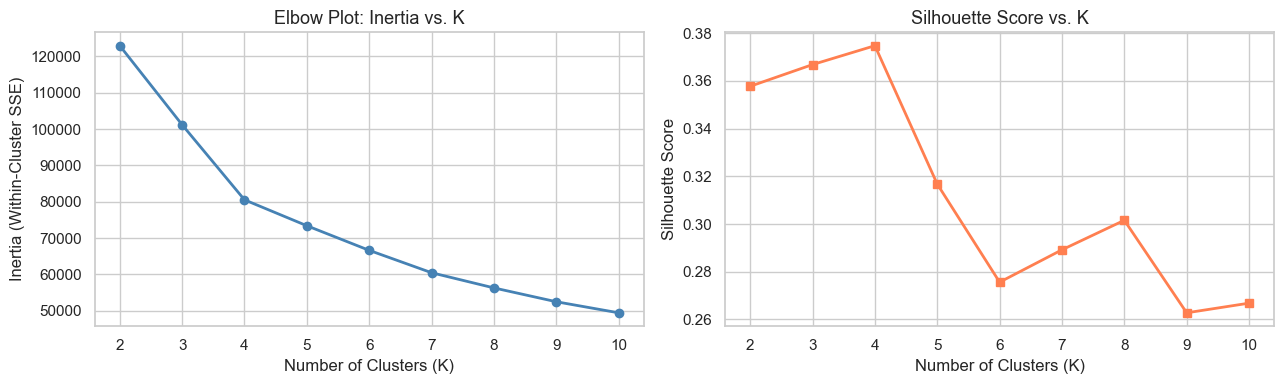

Saved: ../progress/figures/kmeans_elbow_silhouette.png


In [ ]:
K_range = range(2, 11)
inertias = []
silhouette_scores = []

print('Fitting K-Means for K = 2 to 10...')
for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels, sample_size=5000, random_state=SEED)
    silhouette_scores.append(sil)
    print(f'  K={k:2d} | Inertia: {km.inertia_:,.0f} | Silhouette: {sil:.4f}')

# plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(K_range), inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Plot: Inertia vs. K', fontsize=13)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-Cluster SSE)')
axes[0].set_xticks(list(K_range))

axes[1].plot(list(K_range), silhouette_scores, marker='s', color='coral', linewidth=2)
axes[1].set_title('Silhouette Score vs. K', fontsize=13)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_range))

plt.tight_layout()
plt.savefig('../progress/figures/kmeans_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../progress/figures/kmeans_elbow_silhouette.png')

In [ ]:
# update
BEST_K = 4

km_final = KMeans(n_clusters=BEST_K, random_state=SEED, n_init=10)
df_cluster['cluster'] = km_final.fit_predict(X_scaled)

print(f'Cluster counts (K={BEST_K}):')
print(df_cluster['cluster'].value_counts().sort_index())

Cluster counts (K=4):
cluster
0    9906
1    8479
2     199
3    2660
Name: count, dtype: int64


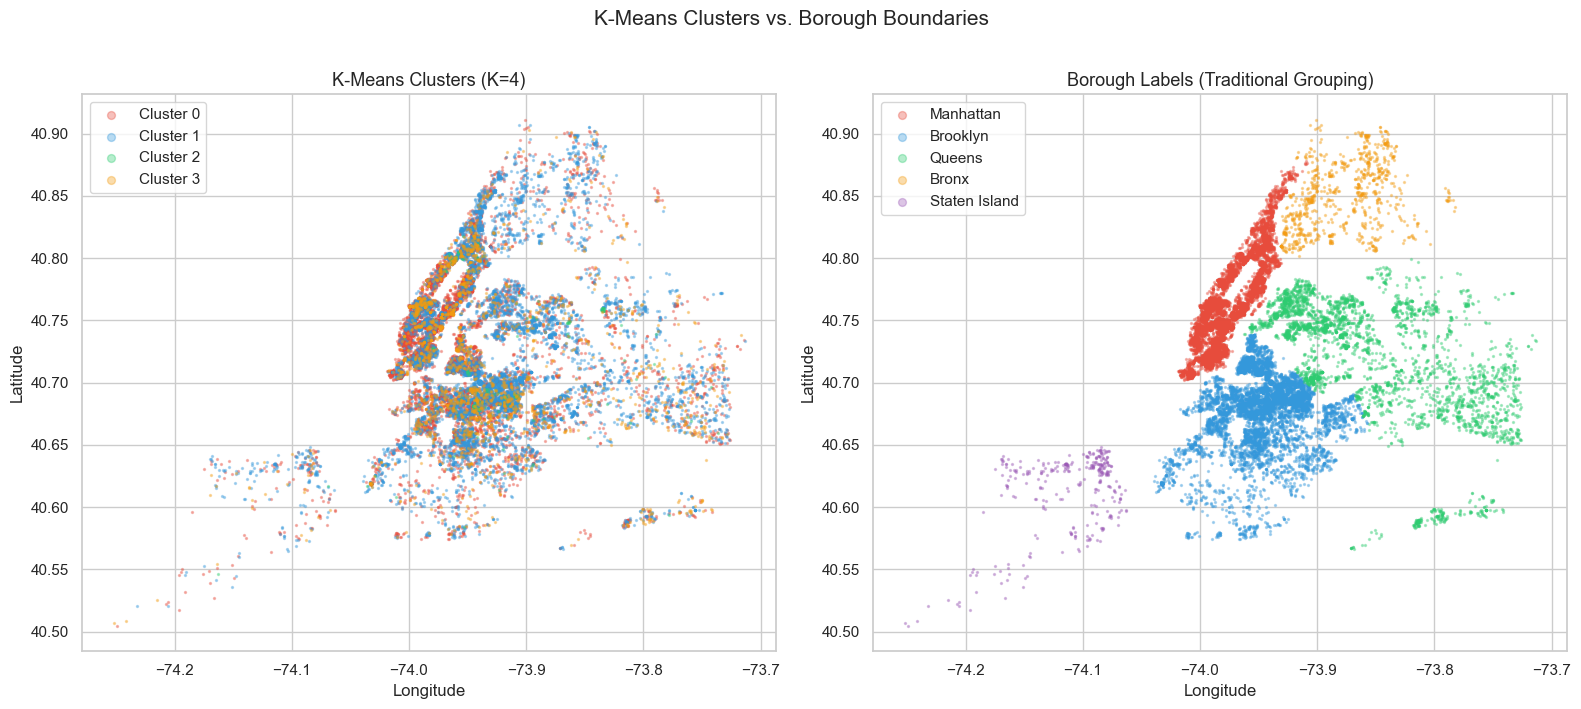

Saved: ../progress/figures/cluster_vs_borough_map.png


In [ ]:
# Filter to 95th pct price to reduce visual distortion from outliers
p95 = df_cluster['price'].quantile(0.95)
df_map = df_cluster[df_cluster['price'] <= p95].copy()

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6',
          '#1abc9c', '#e67e22', '#34495e', '#95a5a6', '#d35400']
cluster_colors = [colors[i] for i in df_map['cluster']]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: K-Means clusters
for k in range(BEST_K):
    mask = df_map['cluster'] == k
    axes[0].scatter(
        df_map.loc[mask, 'longitude'],
        df_map.loc[mask, 'latitude'],
        c=colors[k], s=2, alpha=0.35, label=f'Cluster {k}'
    )
axes[0].set_title(f'K-Means Clusters (K={BEST_K})', fontsize=13)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].legend(markerscale=4, loc='upper left')

# Right: Borough labels 
borough_colors = {
    'Manhattan': '#e74c3c',
    'Brooklyn': '#3498db',
    'Queens': '#2ecc71',
    'Bronx': '#f39c12',
    'Staten Island': '#9b59b6'
}
for borough, color in borough_colors.items():
    mask = df_map['neighbourhood_group_cleansed'] == borough
    axes[1].scatter(
        df_map.loc[mask, 'longitude'],
        df_map.loc[mask, 'latitude'],
        c=color, s=2, alpha=0.35, label=borough
    )
axes[1].set_title('Borough Labels (Traditional Grouping)', fontsize=13)
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].legend(markerscale=4, loc='upper left')

plt.suptitle('K-Means Clusters vs. Borough Boundaries', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('../progress/figures/cluster_vs_borough_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../progress/figures/cluster_vs_borough_map.png')

In [ ]:
# Merge cluster labels back to original df for profiling
df_orig = df[[
    'price', 'log_price', 'room_type', 'neighbourhood_group_cleansed',
    'accommodates', 'bedrooms', 'bathrooms', 'latitude', 'longitude'
]].copy()
df_orig = df_orig.dropna(subset=['price'])
df_orig = df_orig[df_orig['room_type'] != 'Hotel room']

df_orig = df_orig.loc[df_cluster.index]
df_orig['cluster'] = df_cluster['cluster'].values

# summary table
profile = df_orig.groupby('cluster').agg(
    n_listings=('price', 'count'),
    median_price=('price', 'median'),
    mean_price=('price', 'mean'),
    median_accommodates=('accommodates', 'median'),
    median_bedrooms=('bedrooms', 'median'),
).round(2)

print('=== Cluster Profile Summary ===')
print(profile.to_string())

# borough composition per cluster
print('\n=== Borough Composition per Cluster (%) ===')
borough_comp = (
    df_orig.groupby(['cluster', 'neighbourhood_group_cleansed'])
    .size()
    .unstack(fill_value=0)
    .apply(lambda x: (x / x.sum() * 100).round(1), axis=1)
)
print(borough_comp.to_string())

# Room type composition per cluster
print('\n=== Room Type Composition per Cluster (%) ===')
room_comp = (
    df_orig.groupby(['cluster', 'room_type'])
    .size()
    .unstack(fill_value=0)
    .apply(lambda x: (x / x.sum() * 100).round(1), axis=1)
)
print(room_comp.to_string())

=== Cluster Profile Summary ===
         n_listings  median_price  mean_price  median_accommodates  median_bedrooms
cluster                                                                            
0              9906         190.0      238.29                  2.0              1.0
1              8479          85.0      168.35                  2.0              1.0
2               199          56.0      141.06                  1.0              1.0
3              2660         350.0      530.98                  6.0              3.0

=== Borough Composition per Cluster (%) ===
neighbourhood_group_cleansed  Bronx  Brooklyn  Manhattan  Queens  Staten Island
cluster                                                                        
0                               2.7      27.9       58.4     9.8            1.2
1                               5.7      41.0       28.4    23.1            1.9
2                               0.0      47.7       28.1    23.1            1.0
3                  

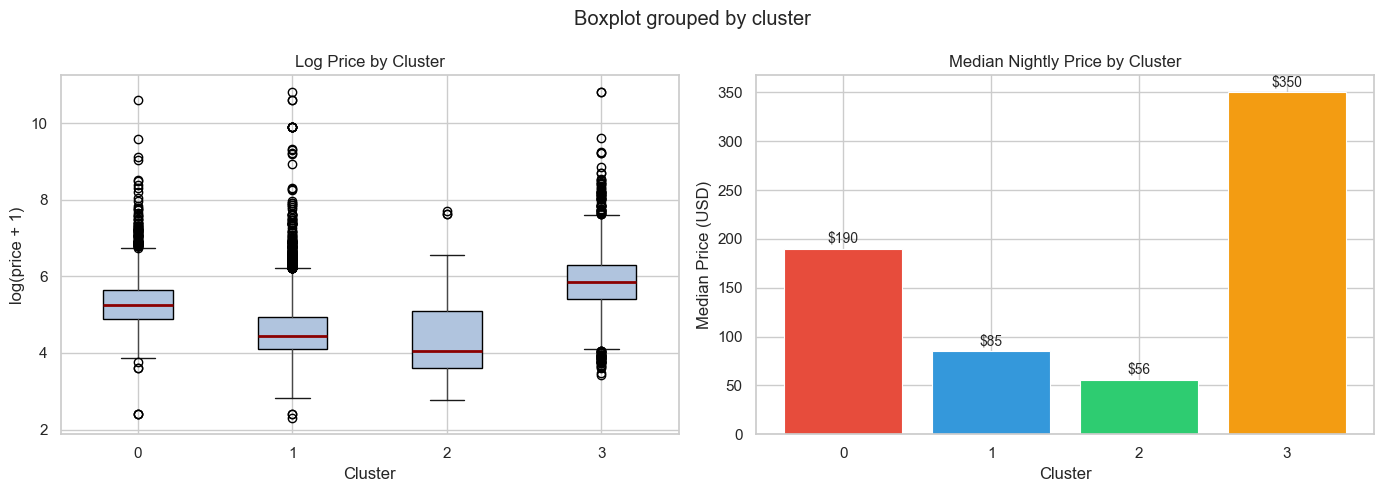

Saved: ../progress/figures/cluster_price_distributions.png


In [ ]:
# Price distribution per cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot: log_price by cluster
df_orig.boxplot(
    column='log_price', by='cluster', ax=axes[0],
    patch_artist=True,
    boxprops=dict(facecolor='lightsteelblue'),
    medianprops=dict(color='darkred', linewidth=2)
)
axes[0].set_title('Log Price by Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('log(price + 1)')
plt.sca(axes[0])
plt.title('Log Price by Cluster')

# Bar chart: median price by cluster
medians = df_orig.groupby('cluster')['price'].median()
bars = axes[1].bar(
    medians.index, medians.values,
    color=[colors[i] for i in medians.index], edgecolor='white', linewidth=0.8
)
axes[1].set_title('Median Nightly Price by Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Median Price (USD)')
axes[1].set_xticks(medians.index)
for bar, val in zip(bars, medians.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 f'${val:.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../progress/figures/cluster_price_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../progress/figures/cluster_price_distributions.png')

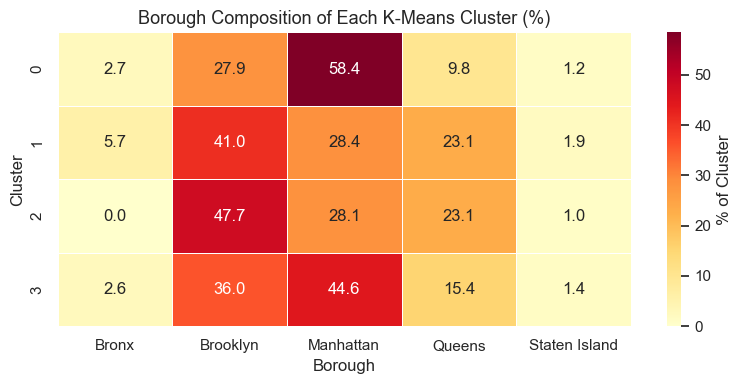

Saved: ../progress/figures/cluster_borough_heatmap.png


In [15]:
# Heatmap: cluster vs borough
crosstab = pd.crosstab(
    df_orig['cluster'],
    df_orig['neighbourhood_group_cleansed'],
    normalize='index'
) * 100

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    crosstab, annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, ax=ax, cbar_kws={'label': '% of Cluster'}
)
ax.set_title('Borough Composition of Each K-Means Cluster (%)', fontsize=13)
ax.set_xlabel('Borough')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.savefig('../progress/figures/cluster_borough_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../progress/figures/cluster_borough_heatmap.png')

In [ ]:
MODEL_FEATURES = [
    'bedrooms', 'bathrooms', 'accommodates',
    'latitude', 'longitude',
    'room_type', 'neighbourhood_group_cleansed'
]

def prepare_X(dataframe, feature_cols, fit_imputer=None):
    """One-hot encode categoricals, impute numerics."""
    df_prep = pd.get_dummies(dataframe[feature_cols], drop_first=False)
    num_cols = [c for c in df_prep.columns if df_prep[c].dtype in [np.float64, np.int64]]
    if fit_imputer is None:
        imp = SimpleImputer(strategy='median')
        df_prep[num_cols] = imp.fit_transform(df_prep[num_cols])
        return df_prep, imp
    else:
        for col in num_cols:
            df_prep[col] = df_prep[col].fillna(df_prep[col].median())
        return df_prep, fit_imputer

RF_PARAMS = dict(n_estimators=100, max_depth=15, min_samples_leaf=5,
                 random_state=SEED, n_jobs=-1)

# Global model (all data, no cluster split)
print('=== A. Global Random Forest (no clustering) ===')

df_model = df_orig[MODEL_FEATURES + ['log_price', 'cluster']].copy()
X_global, imp_global = prepare_X(df_model, MODEL_FEATURES)
y_global = df_model['log_price'].values

X_tr_g, X_te_g, y_tr_g, y_te_g, idx_tr, idx_te = train_test_split(
    X_global, y_global, df_model.index,
    test_size=0.2, random_state=SEED
)
cluster_te = df_model.loc[idx_te, 'cluster'].values

rf_global = RandomForestRegressor(**RF_PARAMS)
rf_global.fit(X_tr_g, y_tr_g)
preds_global = rf_global.predict(X_te_g)

rmse_global = np.sqrt(mean_squared_error(y_te_g, preds_global))
r2_global = r2_score(y_te_g, preds_global)
print(f'  Global Test RMSE: {rmse_global:.4f} | R²: {r2_global:.4f}')

=== A. Global Random Forest (no clustering) ===
  Global Test RMSE: 0.4433 | R²: 0.6916


In [ ]:
# Per-cluster models
print('\n=== B. Per-Cluster Random Forest Models ===')

cluster_results = []
all_preds_cluster = np.full(len(y_te_g), np.nan)

for k in sorted(df_model['cluster'].unique()):
    # Training set: only rows in cluster k
    cluster_train_mask = df_model.loc[idx_tr, 'cluster'] == k
    X_tr_k = X_tr_g[cluster_train_mask.values]
    y_tr_k = y_tr_g[cluster_train_mask.values]

    # Test set: only test rows belonging to cluster k
    test_cluster_mask = cluster_te == k
    X_te_k = X_te_g[test_cluster_mask]
    y_te_k = y_te_g[test_cluster_mask]

    if len(X_tr_k) < 50 or len(X_te_k) < 10:
        print(f'  Cluster {k}: Too few samples (train={len(X_tr_k)}, test={len(X_te_k)}), skipping.')
        continue

    rf_k = RandomForestRegressor(**RF_PARAMS)
    rf_k.fit(X_tr_k, y_tr_k)
    preds_k = rf_k.predict(X_te_k)

    all_preds_cluster[test_cluster_mask] = preds_k

    rmse_k = np.sqrt(mean_squared_error(y_te_k, preds_k))
    r2_k = r2_score(y_te_k, preds_k)
    n_train = len(X_tr_k)
    cluster_results.append({'cluster': k, 'n_train': n_train,
                             'n_test': len(X_te_k),
                             'RMSE': rmse_k, 'R2': r2_k})
    print(f'  Cluster {k}: n_train={n_train:5d} | Test RMSE={rmse_k:.4f} | R²={r2_k:.4f}')

results_df = pd.DataFrame(cluster_results)

# Overall RMSE from per-cluster predictions (only where predictions exist)
valid_mask = ~np.isnan(all_preds_cluster)
rmse_cluster_overall = np.sqrt(mean_squared_error(y_te_g[valid_mask], all_preds_cluster[valid_mask]))
r2_cluster_overall = r2_score(y_te_g[valid_mask], all_preds_cluster[valid_mask])

print(f'\n  Combined Per-Cluster RMSE: {rmse_cluster_overall:.4f} | R²: {r2_cluster_overall:.4f}')
print(f'\n  Global RMSE (no clustering): {rmse_global:.4f} | R²: {r2_global:.4f}')
improvement = rmse_global - rmse_cluster_overall
print(f'  RMSE Improvement from clustering: {improvement:+.4f}')


=== B. Per-Cluster Random Forest Models ===
  Cluster 0: n_train= 7916 | Test RMSE=0.3978 | R²=0.4540
  Cluster 1: n_train= 6781 | Test RMSE=0.4720 | R²=0.6091
  Cluster 2: n_train=  169 | Test RMSE=0.6110 | R²=0.4754
  Cluster 3: n_train= 2129 | Test RMSE=0.4756 | R²=0.6125

  Combined Per-Cluster RMSE: 0.4405 | R²: 0.6955

  Global RMSE (no clustering): 0.4433 | R²: 0.6916
  RMSE Improvement from clustering: +0.0028


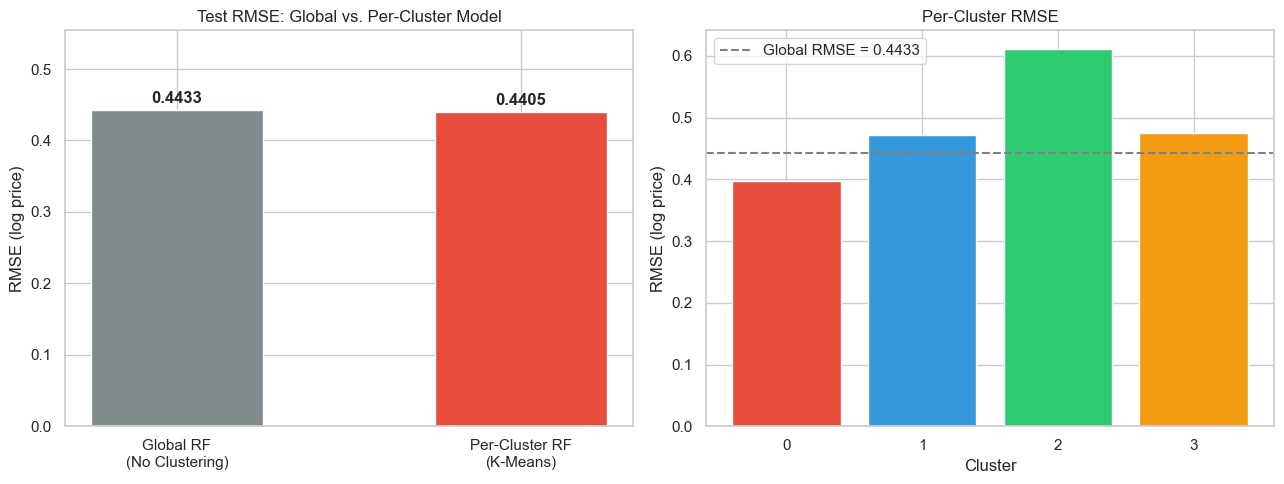

Saved: ../progress/figures/cluster_vs_global_rmse.png


In [ ]:
# Comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# RMSE comparison
model_names = ['Global RF\n(No Clustering)', 'Per-Cluster RF\n(K-Means)']
rmse_vals = [rmse_global, rmse_cluster_overall]
bar_colors = ['#7f8c8d', '#e74c3c']
bars = axes[0].bar(model_names, rmse_vals, color=bar_colors, edgecolor='white', width=0.5)
axes[0].set_title('Test RMSE: Global vs. Per-Cluster Model', fontsize=12)
axes[0].set_ylabel('RMSE (log price)')
axes[0].set_ylim(0, max(rmse_vals) * 1.25)
for bar, val in zip(bars, rmse_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Per-cluster RMSE breakdown
if not results_df.empty:
    axes[1].bar(
        results_df['cluster'].astype(str),
        results_df['RMSE'],
        color=[colors[i] for i in results_df['cluster']],
        edgecolor='white'
    )
    axes[1].axhline(rmse_global, color='gray', linestyle='--', linewidth=1.5,
                    label=f'Global RMSE = {rmse_global:.4f}')
    axes[1].set_title('Per-Cluster RMSE', fontsize=12)
    axes[1].set_xlabel('Cluster')
    axes[1].set_ylabel('RMSE (log price)')
    axes[1].legend()

plt.tight_layout()
plt.savefig('../progress/figures/cluster_vs_global_rmse.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../progress/figures/cluster_vs_global_rmse.png')

In [20]:
print('=' * 60)
print('UNSUPERVISED LEARNING SUMMARY')
print('=' * 60)
print(f'  Method: K-Means Clustering (K={BEST_K})')
print(f'  Features: lat, lon, accommodates, bedrooms, bathrooms, room_type (OHE)')
print(f'  Global RF RMSE:    {rmse_global:.4f}')
print(f'  Per-Cluster RMSE:  {rmse_cluster_overall:.4f}')
print(f'  RMSE Improvement:  {rmse_global - rmse_cluster_overall:+.4f}')
print()
print('Cluster Profiles:')
print(results_df[['cluster', 'n_train', 'n_test', 'RMSE', 'R2']].to_string(index=False))
print()
print('See figures/:')
print('  - kmeans_elbow_silhouette.png')
print('  - cluster_vs_borough_map.png')
print('  - cluster_price_distributions.png')
print('  - cluster_borough_heatmap.png')
print('  - cluster_vs_global_rmse.png')

UNSUPERVISED LEARNING SUMMARY
  Method: K-Means Clustering (K=4)
  Features: lat, lon, accommodates, bedrooms, bathrooms, room_type (OHE)
  Global RF RMSE:    0.4433
  Per-Cluster RMSE:  0.4405
  RMSE Improvement:  +0.0028

Cluster Profiles:
 cluster  n_train  n_test     RMSE       R2
       0     7916    1990 0.397779 0.453972
       1     6781    1698 0.472040 0.609071
       2      169      30 0.611025 0.475439
       3     2129     531 0.475620 0.612453

See figures/:
  - kmeans_elbow_silhouette.png
  - cluster_vs_borough_map.png
  - cluster_price_distributions.png
  - cluster_borough_heatmap.png
  - cluster_vs_global_rmse.png
